## Bank Customer Churn Prediction Using Machine Learning: A Data-Driven Customer Retention Strategy

## Problem Statement

Customer churn is a major challenge for banking and financial institutions. When customers close their bank accounts or stop using banking services, it can lead to a loss of revenue and increased customer acquisition costs.

Many banks identify customer churn only after the customer has already left. At that point, it becomes difficult to take corrective action.

## Problem

The bank lacks a predictive system to identify customers who are likely to leave the bank in advance.

## Solution

Build a machine learning model using customer demographic, financial, and account-related data to predict whether a customer is likely to churn. The predictions can help the bank take proactive customer retention measures.

## Objectives

The main objectives of this project are:

* To analyze customer demographic and financial information.
* To understand the factors influencing customer churn.
* To identify patterns in customer behavior and account activity.
* To build a machine learning classification model to predict customer churn.
* To evaluate the model using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
* To identify important features that contribute to customer churn.
* To support data-driven customer retention strategies for the bank.

## Dataset Description

The dataset used for this project is the **Bank Customer Churn Modelling Dataset**.

It contains customer information from a bank and is used to predict whether a customer will leave the bank.

### Dataset Overview

- Each row represents one bank customer.
- Each column represents customer demographic, financial, or banking-related information.
- The dataset contains numerical and categorical features.
- The target variable is `Exited`.
- This is a binary classification problem.

### Dataset Details

| Property | Description |
|---|---|
| Dataset Name | Bank Customer Churn Modelling Dataset |
| File Name | `Churn_Modelling.csv` |
| Number of Records | 10,000 |
| Number of Columns | 14 |
| Target Variable | `Exited` |
| Problem Type | Binary Classification |
| Business Domain | Banking and Customer Retention |

### Project Goal

The goal of this project is to build a machine learning model that predicts whether a bank customer is likely to leave the bank. The predictions can help the bank identify customers at risk of churn and develop suitable customer retention strategies.

## Column Description

| Column Name | Data Type | Description |
|---|---|---|
| `RowNumber` | Numerical | Sequential row number assigned to each customer record |
| `CustomerId` | Numerical | Unique identification number assigned to each customer |
| `Surname` | Categorical | Last name of the customer |
| `CreditScore` | Numerical | Credit score of the customer, representing creditworthiness |
| `Geography` | Categorical | Country or region where the customer is located |
| `Gender` | Categorical | Gender of the customer |
| `Age` | Numerical | Age of the customer in years |
| `Tenure` | Numerical | Number of years the customer has been associated with the bank |
| `Balance` | Numerical | Amount of money maintained in the customer's bank account |
| `NumOfProducts` | Numerical | Number of banking products used by the customer |
| `HasCrCard` | Binary (0/1) | Indicates whether the customer has a credit card |
| `IsActiveMember` | Binary (0/1) | Indicates whether the customer is an active bank member |
| `EstimatedSalary` | Numerical | Estimated annual salary of the customer |
| `Exited` | Binary (Target) | Indicates whether the customer left the bank |

## Target Variable Explanation

The target variable in this project is `Exited`.

The `Exited` column indicates whether a customer has left the bank.

- `1` → Customer has exited the bank.
- `0` → Customer has remained with the bank.

Since the target variable contains two possible outcomes, this project is a **binary classification problem**.

The objective of the machine learning model is to predict whether a customer is likely to leave the bank based on demographic, financial, and banking-related features.

## Exploratory Data Analysis (EDA)

EDA helps understand:

* Data quality

* Customer behavior

* Factors influencing churn before building the model.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline 
#to display imagine inside jupyter notebook

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,precision_score

## Importing the Dataset

In [2]:
ds = pd.read_csv(r"C:\Users\DELL\.ipynb_checkpoints\Desktop\ML\Bank Customer Churn\Churn_Modelling.csv")

In [3]:
ds.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2474,2475,15693199,Shao,739,France,Female,37,8,0.00,2,1,0,191557.10,1
4063,4064,15575691,Palerma,689,France,Female,58,5,0.00,2,0,1,49848.86,0
5603,5604,15608408,Lazareva,598,Spain,Male,39,1,0.00,2,1,0,159130.32,0
1320,1321,15596493,Wisdom,687,France,Female,47,7,0.00,2,1,1,177624.01,0
7877,7878,15793070,Fiorentino,494,Spain,Female,41,2,69974.66,2,1,0,188426.13,1
4696,4697,15699467,Connor,631,Spain,Female,41,0,0.00,1,0,0,87959.83,0
9539,9540,15590337,Golubov,659,France,Male,29,6,123192.12,1,1,1,56971.41,1
805,806,15756026,Hooper,790,Spain,Female,46,9,0.00,1,0,0,14679.81,1
3554,3555,15662865,Storey,658,Spain,Male,36,1,0.00,2,0,1,84927.42,0
3971,3972,15790809,Lo Duca,685,Spain,Male,40,7,74896.92,1,1,0,198694.20,0


In [4]:
ds.shape

(10000, 14)

In [5]:
ds.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [6]:
ds.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
# Select numerical columns
numerical_columns = ds.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

## Numerical Columns Distribution

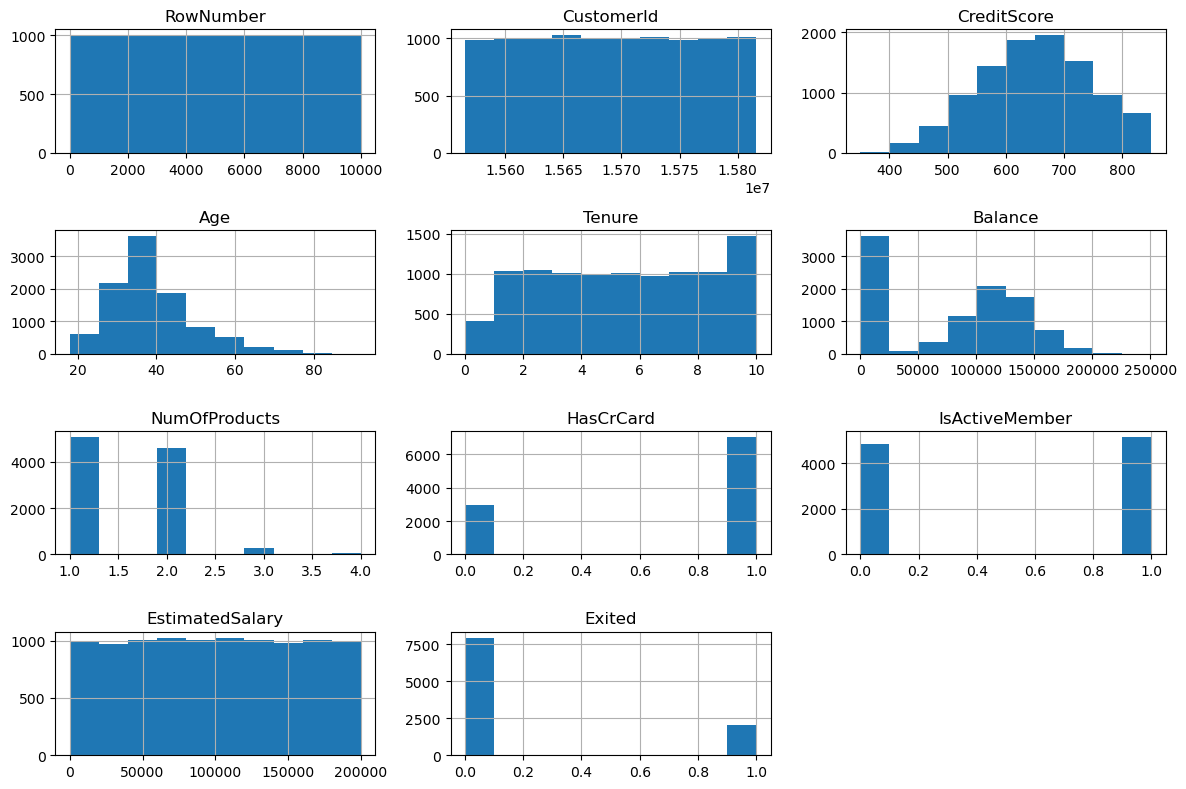

In [9]:
# Plot histograms for numerical columns
import matplotlib.pyplot as plt

ds[numerical_columns].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Categorical Columns

In [10]:
# Select categorical columns
categorical_columns = ds.select_dtypes(include=['object', 'category']).columns

categorical_columns

Index(['Surname', 'Geography', 'Gender'], dtype='object')

In [11]:
# Display unique values in categorical columns
for col in categorical_columns:
    print(f"\n{col}:")
    print(ds[col].unique())


Surname:
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']

Geography:
['France' 'Spain' 'Germany']

Gender:
['Female' 'Male']


## Correlation Analysis

In [12]:
# Correlation matrix for numerical columns
correlation = ds[numerical_columns].corr()

correlation

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


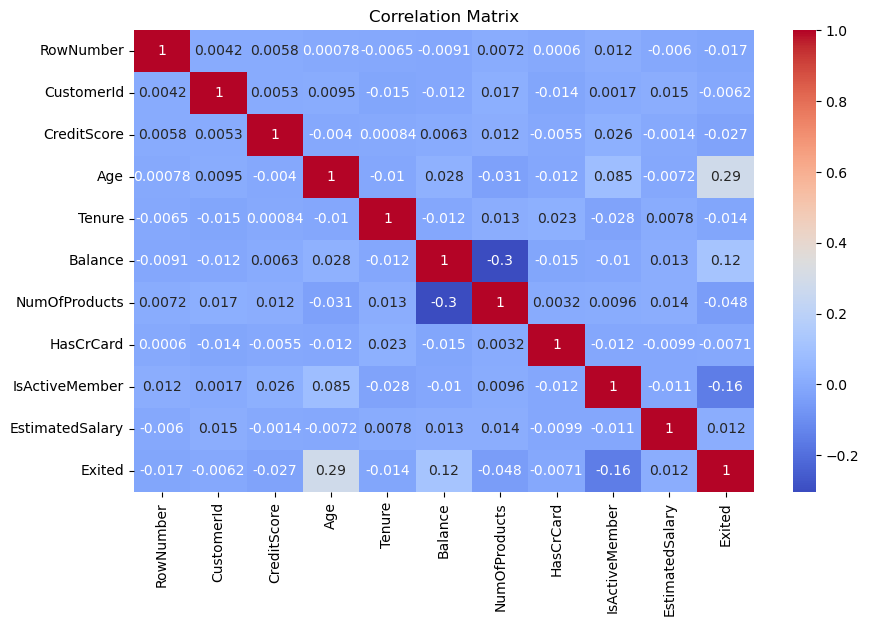

In [13]:
# Visualize correlation matrix
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Customer Churn Distribution

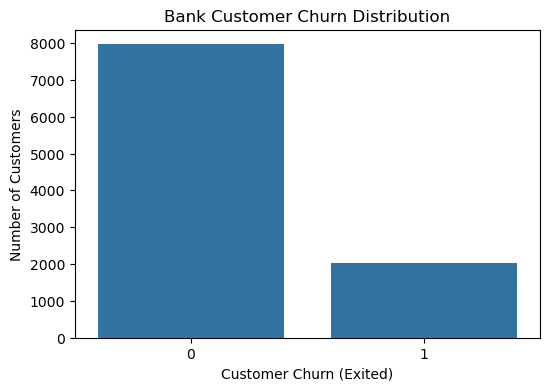

In [14]:
# Churn distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=ds, x='Exited')

plt.title('Bank Customer Churn Distribution')
plt.xlabel('Customer Churn (Exited)')
plt.ylabel('Number of Customers')

plt.show()

## Churn by Geography

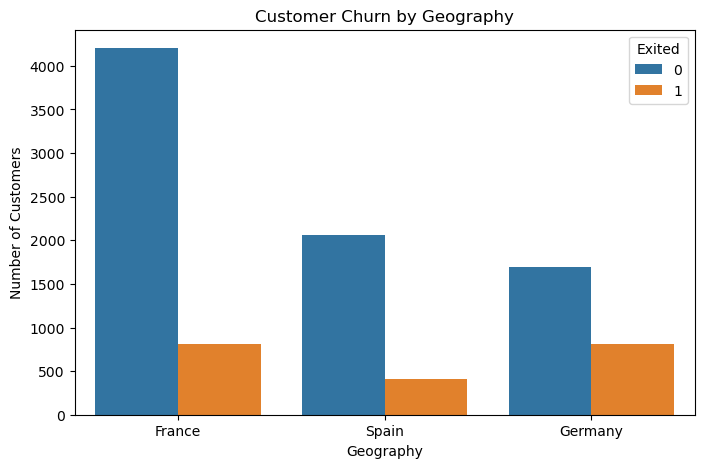

In [15]:
# Churn by Geography

plt.figure(figsize=(8, 5))

sns.countplot(data=ds, x='Geography', hue='Exited')

plt.title('Customer Churn by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')

plt.show()

## Churn by Age 

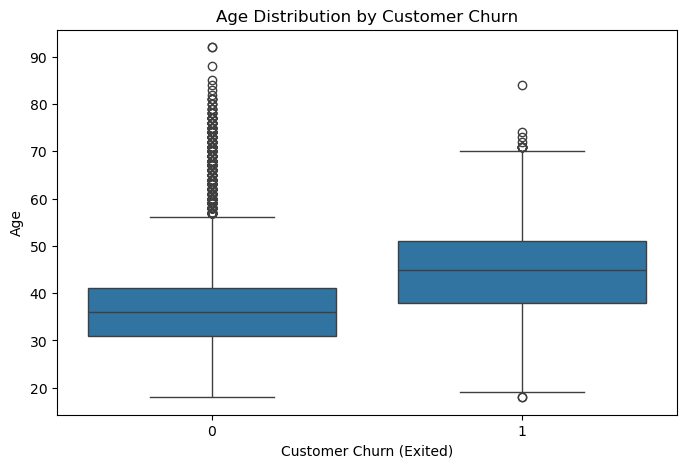

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=ds, x='Exited', y='Age')

plt.title('Age Distribution by Customer Churn')
plt.xlabel('Customer Churn (Exited)')
plt.ylabel('Age')

plt.show()

## Churn by Credit Score

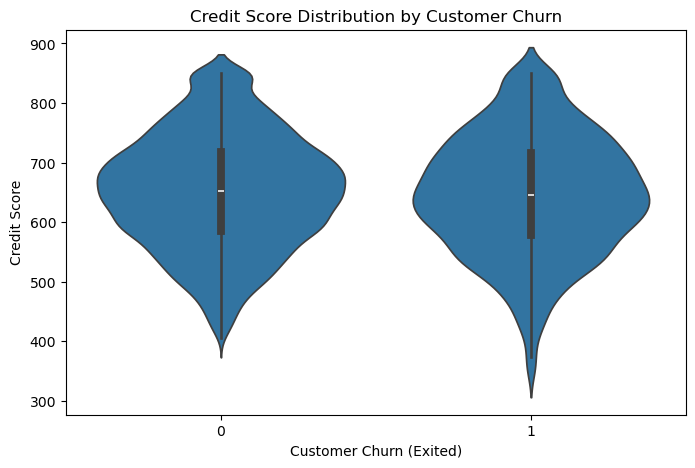

In [17]:
plt.figure(figsize=(8, 5))

sns.violinplot(data=ds, x='Exited', y='CreditScore')

plt.title('Credit Score Distribution by Customer Churn')
plt.xlabel('Customer Churn (Exited)')
plt.ylabel('Credit Score')

plt.show()

## Data Preprocessing and Feature Engineering

In [18]:
# Display all column names
ds.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [19]:
# Check whether unnecessary columns exist
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']

ds = ds.drop(columns=[col for col in columns_to_drop if col in ds.columns])

ds.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [20]:
# Check data types of all columns
ds.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

## Feature Engineering

In [21]:
## Feature Engineering

# Separate independent and dependent variables
X = ds.drop('Exited', axis=1)
y = ds['Exited']

# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=['Geography', 'Gender'],
    drop_first=True
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 11)
Target shape: (10000,)


In [22]:
# Display feature names after encoding

X.columns.tolist()

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male']

In [23]:
# Check missing values after encoding

X.isnull().sum()

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (8000, 11)
Testing data shape: (2000, 11)


In [25]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [26]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print(y_pred_logistic[:10])

[0 0 0 0 0 0 0 0 0 0]


In [27]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.808

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



## Display the Confusion Matrix

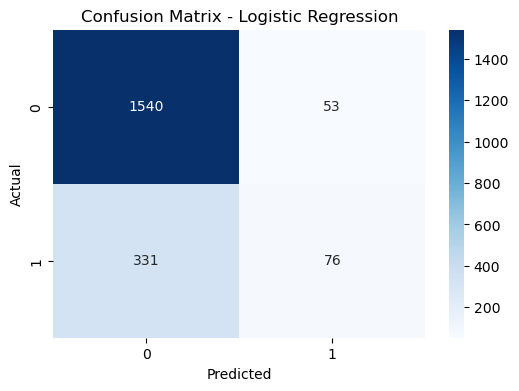

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Train Random Forest Model

In [29]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [30]:
y_pred_rf = random_forest_model.predict(X_test)

In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8645

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582
1,Random Forest,0.8645,0.783333,0.461916,0.581144


In [33]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.236485
7,EstimatedSalary,0.147016
0,CreditScore,0.142756
3,Balance,0.141756
4,NumOfProducts,0.130410
2,Tenure,0.081817
6,IsActiveMember,0.039933
8,Geography_Germany,0.028923
5,HasCrCard,0.018799
10,Gender_Male,0.018483


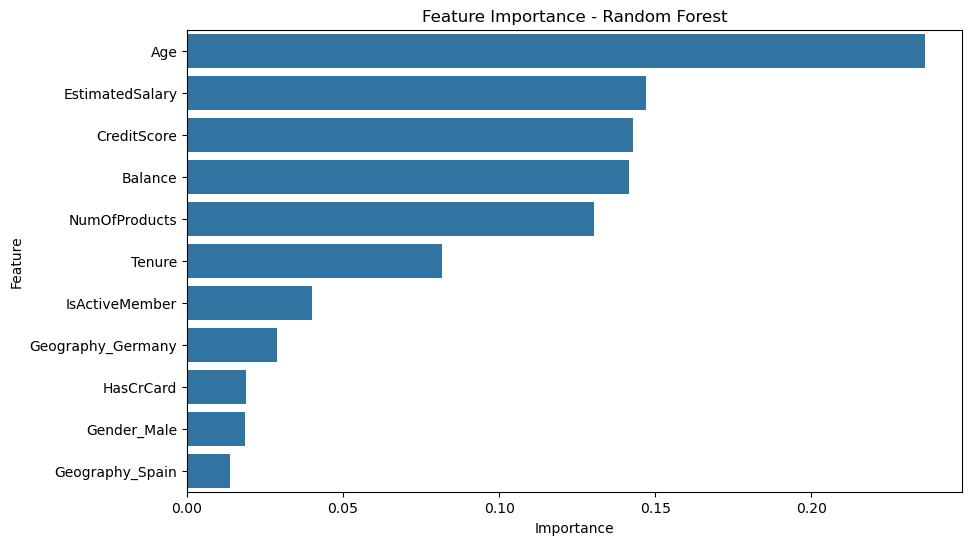

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Improve the Model with Hyperparameter Tuning

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [37]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [38]:
best_rf_model = grid_search.best_estimator_

print("Best Random Forest model selected.")

Best Random Forest model selected.


In [39]:
y_pred_best_rf = best_rf_model.predict(X_test)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.866

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.58       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



## Final Model Comparison

In [40]:
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf)
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582
1,Random Forest,0.8645,0.783333,0.461916,0.581144
2,Tuned Random Forest,0.8660,0.793249,0.461916,0.583851


In [41]:
best_model = best_rf_model

print("Final model selected: Tuned Random Forest")

Final model selected: Tuned Random Forest


## Save the Model

In [42]:
import joblib

joblib.dump(best_model, 'bank_customer_churn_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


## Prediction for a New Customer

In [43]:
sample_customer = pd.DataFrame({
    'CreditScore': [650],
    'Geography': ['France'],
    'Gender': ['Female'],
    'Age': [40],
    'Tenure': [5],
    'Balance': [75000],
    'NumOfProducts': [2],
    'HasCrCard': [1],
    'IsActiveMember': [1],
    'EstimatedSalary': [60000]
})

In [44]:
sample_customer_encoded = pd.get_dummies(
    sample_customer,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [45]:
sample_customer_encoded = sample_customer_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

In [46]:
sample_prediction = best_model.predict(sample_customer_encoded)

if sample_prediction[0] == 1:
    print("Prediction: Customer is likely to churn.")
else:
    print("Prediction: Customer is likely to stay.")

Prediction: Customer is likely to stay.


In [47]:
sample_probability = best_model.predict_proba(sample_customer_encoded)

print("Probability of Staying:", sample_probability[0][0])
print("Probability of Churning:", sample_probability[0][1])

Probability of Staying: 0.951140873015873
Probability of Churning: 0.048859126984126984


In [48]:
print(f"Churn Probability: {sample_probability[0][1] * 100:.2f}%")

Churn Probability: 4.89%


## Conclusion

This project developed a machine learning model to predict bank customer churn using customer demographic, financial, and account activity data. Exploratory Data Analysis was performed to understand the distribution of features and identify patterns related to customer attrition. Categorical variables were encoded, numerical features were prepared, and multiple machine learning models were trained and evaluated. Logistic Regression and Random Forest models were compared using accuracy, precision, recall, and F1-score. Hyperparameter tuning was applied to improve the Random Forest model. The final model can help banks identify customers who are at risk of leaving and support targeted customer retention strategies.